# Stock Health Diagnostic Tool
## ACC102 Mini Assignment – Track 4

**Analytical Problem:** Compare the risk-return performance of major tech stocks to help retail investors make informed decisions.

**Target User:** Individual retail investors with no professional finance background.

**Data Source:** Yahoo Finance via yfinance library. Accessed April 2026.

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 1: Data Acquisition & Cleaning

In [4]:
# Download multiple stock data from Yahoo Finance
# Data source: Yahoo Finance via yfinance library
# Access date: April 2026

TICKERS = ["AAPL", "MSFT", "NVDA", "TSLA"]
START_DATE = "2022-01-01"
END_DATE = "2026-04-20"

# Download all tickers at once
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE)

# Extract closing prices only
close_df = raw["Close"].dropna()

print(f"Tickers: {TICKERS}")
print(f"Total trading days: {len(close_df)}")
print(f"Period: {close_df.index[0].date()} to {close_df.index[-1].date()}")
print("\nFirst 5 rows:")
close_df.head()

[*********************100%***********************]  4 of 4 completed

Tickers: ['AAPL', 'MSFT', 'NVDA', 'TSLA']
Total trading days: 1076
Period: 2022-01-03 to 2026-04-17

First 5 rows:


Ticker,AAPL,MSFT,NVDA,TSLA
Date,,,,
2022-01-03,178.103699,323.160706,30.061138,399.926666
2022-01-04,175.843216,317.619537,29.231789,383.196655
2022-01-05,171.165878,305.426727,27.549137,362.706665
2022-01-06,168.308472,303.013306,28.121998,354.899994
2022-01-07,168.474838,303.167816,27.192848,342.320007


## Step 2: Key Statistics Calculation
Metrics include annualized return, volatility, maximum drawdown, and Sharpe Ratio.

In [5]:
# Calculate key statistics for each ticker
RISK_FREE_RATE = 0.05

results = []

for ticker in TICKERS:
    prices = close_df[ticker].dropna()
    daily_return = prices.pct_change().dropna()
    
    total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
    ann_return = (1 + total_return) ** (252 / len(prices)) - 1
    ann_vol = daily_return.std() * np.sqrt(252)
    
    rolling_max = prices.cummax()
    max_drawdown = ((prices - rolling_max) / rolling_max).min()
    
    sharpe = (ann_return - RISK_FREE_RATE) / ann_vol
    
    results.append({
        "Ticker": ticker,
        "Ann. Return": f"{ann_return:.2%}",
        "Ann. Volatility": f"{ann_vol:.2%}",
        "Max Drawdown": f"{max_drawdown:.2%}",
        "Sharpe Ratio": f"{sharpe:.2f}"
    })

stats_df = pd.DataFrame(results).set_index("Ticker")
print("=" * 60)
print("          Key Statistics Comparison")
print("=" * 60)
print(stats_df.to_string())
print("=" * 60)

          Key Statistics Comparison
       Ann. Return Ann. Volatility Max Drawdown Sharpe Ratio
Ticker                                                      
AAPL        10.26%          28.28%      -33.36%         0.19
MSFT         6.50%          27.25%      -35.58%         0.05
NVDA        56.17%          52.84%      -62.70%         0.97
TSLA         0.04%          60.56%      -72.97%        -0.08


## Step 3: Normalized Price Comparison
All prices normalized to 100 at start date for fair cross-stock comparison.

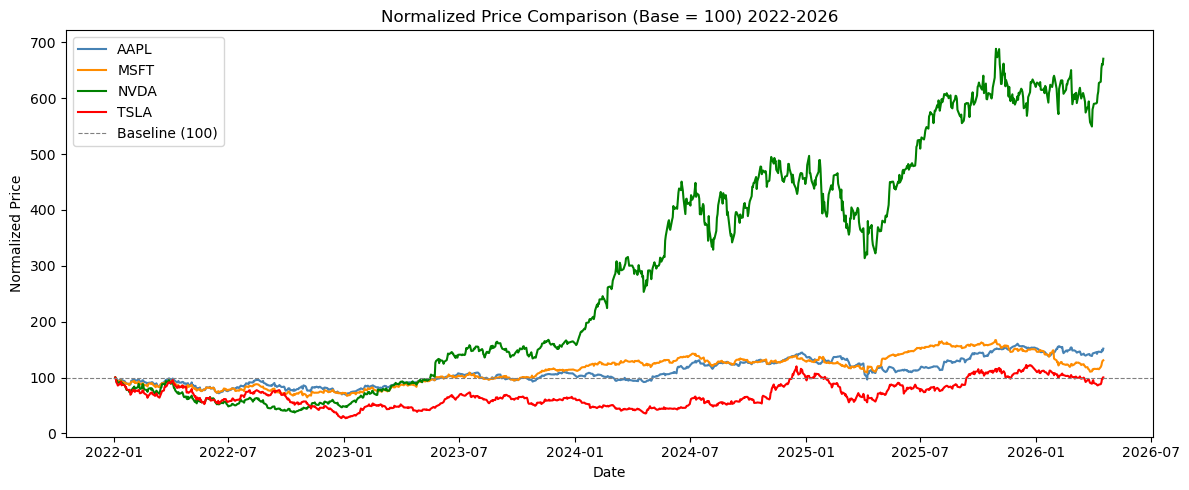

In [6]:
# Normalize prices to 100 at start (for fair comparison)
normalized = close_df / close_df.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['steelblue', 'darkorange', 'green', 'red']
for ticker, color in zip(TICKERS, colors):
    ax.plot(normalized.index, normalized[ticker], label=ticker, linewidth=1.5, color=color)

ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, label='Baseline (100)')
ax.set_title('Normalized Price Comparison (Base = 100) 2022-2026')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4: Linear Regression Trend Forecast
Simple linear regression used to estimate 30-day price trend. For educational purposes only.

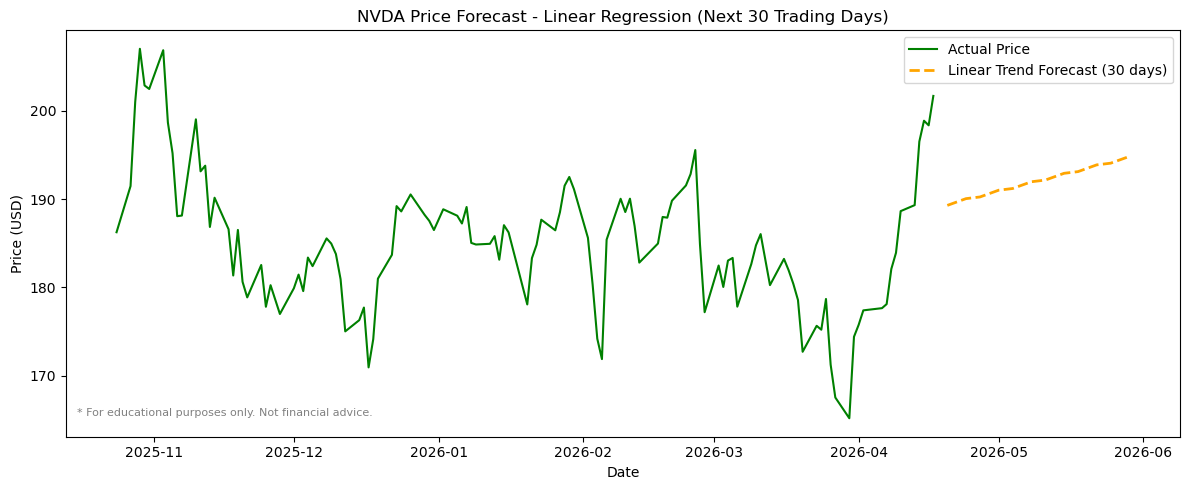


Current Price: $201.68
Predicted Price in 30 days: $194.83
Predicted Change: -3.40%

* Linear regression captures trend only. Not financial advice.


In [7]:
from sklearn.linear_model import LinearRegression

# Use NVDA as example for trend prediction
target = "NVDA"
prices = close_df[target].dropna()

# Prepare data: X = day index, y = price
X = np.arange(len(prices)).reshape(-1, 1)
y = prices.values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predict next 30 trading days
future_X = np.arange(len(prices), len(prices) + 30).reshape(-1, 1)
future_pred = model.predict(future_X)

# Create future date index
last_date = prices.index[-1]
future_dates = pd.bdate_range(start=last_date, periods=31)[1:]

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prices.index[-120:], prices[-120:], label='Actual Price', color='green', linewidth=1.5)
ax.plot(future_dates, future_pred, label='Linear Trend Forecast (30 days)',
        color='orange', linestyle='--', linewidth=2)
ax.set_title(f'{target} Price Forecast - Linear Regression (Next 30 Trading Days)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()

# Disclaimer
ax.text(0.01, 0.05, '* For educational purposes only. Not financial advice.',
        transform=ax.transAxes, fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print(f"\nCurrent Price: ${prices.iloc[-1]:.2f}")
print(f"Predicted Price in 30 days: ${future_pred[-1]:.2f}")
print(f"Predicted Change: {((future_pred[-1]/prices.iloc[-1])-1):.2%}")
print("\n* Linear regression captures trend only. Not financial advice.")

## Step 5: Return Correlation Matrix

A correlation matrix measures how similarly two stocks move on a daily basis.
Values range from -1 (opposite directions) to +1 (identical movement).

This analysis helps investors understand diversification benefits — 
holding stocks with lower correlation reduces overall portfolio risk.

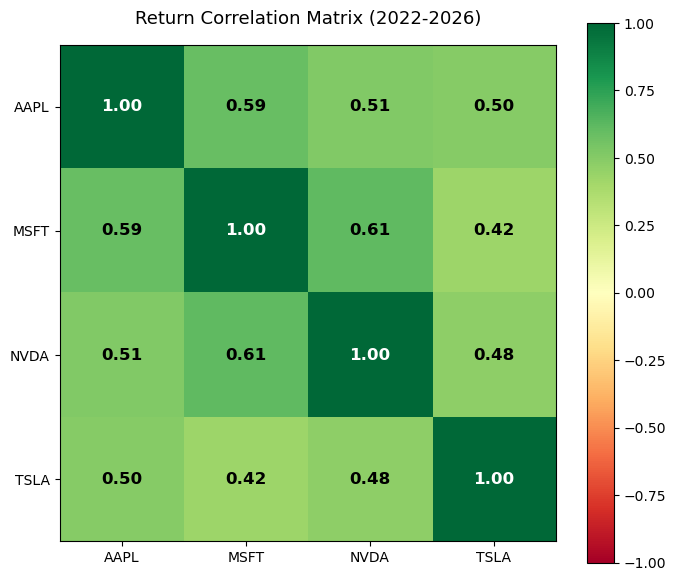


Interpretation:
- Values close to 1.0: stocks move together (low diversification benefit)
- Values close to 0.0: stocks move independently (good diversification)
- Values close to -1.0: stocks move in opposite directions (hedge)


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlation matrix of daily returns
returns_df = close_df.pct_change().dropna()
corr_matrix = returns_df.corr()

# Plot heatmap manually
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)

# Add colorbar
plt.colorbar(im, ax=ax)

# Add labels
tickers_list = corr_matrix.columns.tolist()
ax.set_xticks(range(len(tickers_list)))
ax.set_yticks(range(len(tickers_list)))
ax.set_xticklabels(tickers_list)
ax.set_yticklabels(tickers_list)

# Add correlation values inside each cell
for i in range(len(tickers_list)):
    for j in range(len(tickers_list)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='black' if abs(val) < 0.7 else 'white')

ax.set_title('Return Correlation Matrix (2022-2026)', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Values close to 1.0: stocks move together (low diversification benefit)")
print("- Values close to 0.0: stocks move independently (good diversification)")
print("- Values close to -1.0: stocks move in opposite directions (hedge)")

## Step 6: Cross-Sector Risk-Return Analysis

To provide a broader market perspective, this analysis expands beyond the initial four stocks 
to cover 13 major US-listed companies across five sectors:

- **Tech**: AAPL, MSFT, NVDA, TSLA
- **Big Tech**: GOOGL, META, AMZN
- **Finance**: JPM, GS
- **Healthcare**: JNJ, PFE
- **Energy**: XOM, CVX

Bubble size represents each stock's Sharpe Ratio — larger bubbles indicate better 
risk-adjusted returns. This cross-sector view helps investors understand not just 
individual stock performance, but how different industries behave under the same 
market conditions (2022–2026).

[*********************100%***********************]  13 of 13 completed


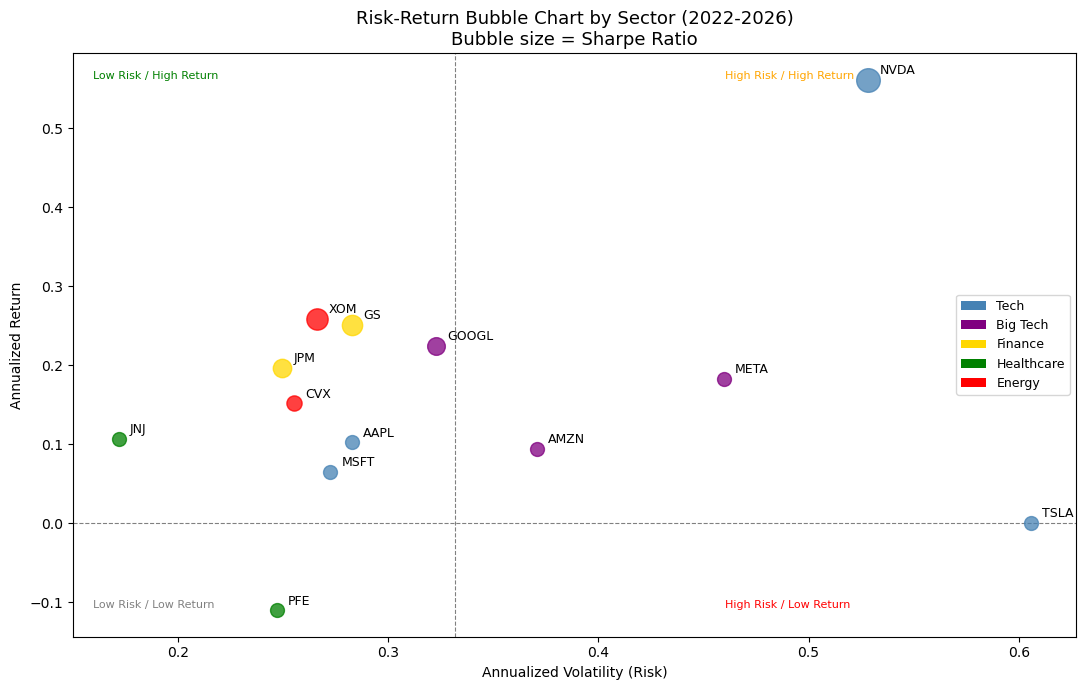

In [10]:
# Expanded stock universe across sectors
EXPANDED_TICKERS = [
    "AAPL", "MSFT", "NVDA", "TSLA",   # Tech
    "GOOGL", "META", "AMZN",            # Big Tech
    "JPM", "GS",                         # Finance
    "JNJ", "PFE",                        # Healthcare
    "XOM", "CVX"                         # Energy
]

# Download expanded data
raw2 = yf.download(EXPANDED_TICKERS, start=START_DATE, end=END_DATE)
close2 = raw2["Close"].dropna()

# Calculate stats for all tickers
ann_returns2, ann_vols2, sharpes2 = [], [], []

for ticker in EXPANDED_TICKERS:
    prices = close2[ticker].dropna()
    daily_ret = prices.pct_change().dropna()
    total_ret = (prices.iloc[-1] / prices.iloc[0]) - 1
    ann_ret = (1 + total_ret) ** (252 / len(prices)) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = (ann_ret - 0.05) / ann_vol
    ann_returns2.append(ann_ret)
    ann_vols2.append(ann_vol)
    sharpes2.append(sharpe)

# Sector colors
sector_colors = {
    "AAPL": "steelblue", "MSFT": "steelblue", "NVDA": "steelblue", "TSLA": "steelblue",
    "GOOGL": "purple", "META": "purple", "AMZN": "purple",
    "JPM": "gold", "GS": "gold",
    "JNJ": "green", "PFE": "green",
    "XOM": "red", "CVX": "red"
}

# Bubble size = Sharpe Ratio (scaled)
bubble_sizes = [max(s * 300, 100) for s in sharpes2]

fig, ax = plt.subplots(figsize=(11, 7))

for i, ticker in enumerate(EXPANDED_TICKERS):
    ax.scatter(ann_vols2[i], ann_returns2[i],
               s=abs(bubble_sizes[i]),
               color=sector_colors[ticker],
               alpha=0.75, zorder=5)
    ax.annotate(ticker, (ann_vols2[i], ann_returns2[i]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

# Quadrant lines
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(x=np.mean(ann_vols2), color='gray', linestyle='--', linewidth=0.8)

# Quadrant labels
ax.text(0.02, 0.97, 'Low Risk / High Return', transform=ax.transAxes, fontsize=8, color='green', va='top')
ax.text(0.65, 0.97, 'High Risk / High Return', transform=ax.transAxes, fontsize=8, color='orange', va='top')
ax.text(0.02, 0.05, 'Low Risk / Low Return', transform=ax.transAxes, fontsize=8, color='gray')
ax.text(0.65, 0.05, 'High Risk / Low Return', transform=ax.transAxes, fontsize=8, color='red')

# Legend for sectors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Tech'),
    Patch(facecolor='purple', label='Big Tech'),
    Patch(facecolor='gold', label='Finance'),
    Patch(facecolor='green', label='Healthcare'),
    Patch(facecolor='red', label='Energy')
]
ax.legend(handles=legend_elements, loc='center right', fontsize=9)

ax.set_title('Risk-Return Bubble Chart by Sector (2022-2026)\nBubble size = Sharpe Ratio', fontsize=13)
ax.set_xlabel('Annualized Volatility (Risk)')
ax.set_ylabel('Annualized Return')
plt.tight_layout()
plt.show()

## Step 7: Portfolio Simulator

In the interactive app, users can allocate custom weights to each stock using sliders.
The portfolio's combined annualized return, volatility, Sharpe ratio, and max drawdown
are calculated in real time, and compared against a chosen benchmark index (S&P 500, NASDAQ, or Dow Jones).

This feature demonstrates how diversification affects overall portfolio risk and return.

## Step 8: Benchmark Comparison & Alpha

Each stock's annualized return is compared against the selected benchmark.
Alpha = Stock Return minus Benchmark Return.
A positive alpha means the stock outperformed the market.